# ✈️ Flight Delay Prediction 

## Problem Statement

Flight delays cost the U.S. airline industry **\$33 billion per year** and directly affect passenger experience, crew scheduling, and airport operations. The ability to predict whether a flight will be significantly delayed (>15 minutes) before it departs enables:

- **Airlines** to proactively re-accommodate passengers and reassign crew.
- **Airports** to optimise gate and ground resource allocation.
- **Passengers** to make informed re-booking decisions.

### Objective
Build a binary classification model that predicts whether a scheduled flight will arrive **more than 15 minutes late** (`ArrDel15 = 1`), using only information available **at the time of scheduling** (no post-departure leakage).

### Dataset
U.S. Bureau of Transportation Statistics (BTS) On-Time Performance data — domestic scheduled flights, 2024 Q1 (~11,600 records, 120 raw features).

### Key Questions
1. Which airlines, airports, and routes are most delay-prone?
2. Do time-of-day, day-of-week, and seasonal patterns predict delays?
3. What operational features (taxi time, aircraft rotation, route distance) matter most?
4. Which model best balances recall vs. precision for business use?


---
## 1. Setup & Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings 

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print("Libraries loaded")

Libraries loaded


In [ ]:
df = pd.read_csv('/data/flight_data_2018_2024.csv')
print(f"Dataset shape: {df.shape}")
df.sample(3)

Dataset shape: (582425, 120)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,...,Div5Airport,Div5AirportID,Div5AirportSeqID,Div5WheelsOn,Div5TotalGTime,Div5LongestGTime,Div5WheelsOff,Div5TailNum,Duplicate,Unnamed: 119
286681,2024,1,1,28,7,2024-01-28,NK,NK,20416,NK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
538532,2024,1,1,11,4,2024-01-11,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
261632,2024,1,1,8,1,2024-01-08,AA,AA_CODESHARE,19805,AA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


---
## 2. Data Understanding

We begin with a structured audit of columns, types, and basic statistics.


In [ ]:
# column overview
print(f"Columns : {df.shape[1]}")
print(f"Rows    : {df.shape[0]}")
print()
df.info(verbose=True, show_counts=True)


Columns : 120
Rows    : 582,425

<class 'pandas.DataFrame'>
RangeIndex: 582425 entries, 0 to 582424
Data columns (total 120 columns):
 #    Column                                              Non-Null Count   Dtype  
---   ------                                              --------------   -----  
 0    Year                                                582425 non-null  int64  
 1    Quarter                                             582425 non-null  int64  
 2    Month                                               582425 non-null  int64  
 3    DayofMonth                                          582425 non-null  int64  
 4    DayOfWeek                                           582425 non-null  int64  
 5    FlightDate                                          582425 non-null  str    
 6    Marketing_Airline_Network                           582425 non-null  str    
 7    Operated_or_Branded_Code_Share_Partners             582425 non-null  str    
 8    DOT_ID_Marketing_Airline      

In [ ]:
# descriptive statistics for important numeric columns
key_cols = ['DepDelay', 'ArrDelay', 'Distance', 'TaxiOut', 'TaxiIn',
            'AirTime', 'CRSElapsedTime', 'CarrierDelay',
            'WeatherDelay', 'NASDelay', 'LateAircraftDelay']
df[key_cols].describe().round(2)

,DepDelay,ArrDelay,Distance,TaxiOut,TaxiIn,AirTime,CRSElapsedTime,CarrierDelay,WeatherDelay,NASDelay,LateAircraftDelay
count,560955.00,558715.00,582425.00,560515.00,560093.00,558715.00,582425.00,134575.00,134575.00,134575.00,134575.00
mean,15.97,10.66,809.34,18.98,8.28,113.29,146.07,24.64,8.02,13.52,30.58
std,66.06,68.65,588.76,11.51,6.95,70.21,72.41,80.81,52.31,30.15,68.25
min,-56.00,-90.00,31.00,1.00,1.00,7.00,26.00,0.00,0.00,0.00,0.00
25%,-6.00,-16.00,377.00,12.00,4.00,62.00,93.00,0.00,0.00,0.00,0.00
50%,-2.00,-5.00,661.00,16.00,6.00,96.00,130.00,2.00,0.00,1.00,1.00
75%,12.00,13.00,1050.00,22.00,10.00,144.00,177.00,21.00,0.00,18.00,35.00
max,3125.00,3136.00,5095.00,213.00,444.00,1338.00,690.00,2972.00,1804.00,1431.00,1741.00


In [ ]:
# missing value audit
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'Missing Count': missing, 'Missing %': pct})

,Missing Count,Missing %
Unnamed: 119,582425,100.0
Div5Airport,582425,100.0
Div4AirportID,582425,100.0
Div4AirportSeqID,582425,100.0
Div4WheelsOn,582425,100.0
...,...,...
DepDel15,21470,3.7
DepDelayMinutes,21470,3.7
DepDelay,21470,3.7
DepTime,21396,3.7


- CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, LateAircraftDelay are 77% null — only populated for delayed flights.
- They are valuable for EDA but can't be used as model features (target leakage).
- ArrDelay / DepDelay are ~4% null — cancelled or diverted flights.
- Diversion kind of columns are >99% null and will be dropped.


---
## 3. Data Cleaning


In [ ]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'])
df['Year']       = df['FlightDate'].dt.year
df['Month']      = df['FlightDate'].dt.month
df['DayofMonth'] = df['FlightDate'].dt.day
df['DayOfWeek']  = df['FlightDate'].dt.dayofweek   # 0=Mon ... 6=Sun

# drop near-empty diverted-leg columns (>95% na valuews)
div_cols = [c for c in df.columns if c.startswith('Div') and c != 'Diverted']
df.drop(columns=div_cols + ['Unnamed: 119'], errors='ignore', inplace=True)

# filter to non-cancelled flights
df_model = df[df['Cancelled'] == 0].copy()
df_model.dropna(subset=['ArrDelay', 'DepDelay'], inplace=True)

# ceate binary target: Arrived >15 min late
df_model['ArrDel15'] = (df_model['ArrDelay'] > 15).astype(int)

print(f"Rows after cleaning : {len(df_model):,}")
print(f"Delayed (>15 min)   : {df_model['ArrDel15'].sum():,}  "f"({df_model['ArrDel15'].mean()*100:.1f}%)")
print(f"On-time             : {(df_model['ArrDel15']==0).sum():,}  "f"({(1-df_model['ArrDel15'].mean())*100:.1f}%)")


Rows after cleaning : 558,715
Delayed (>15 min)   : 130,480  (23.4%)
On-time             : 428,235  (76.6%)


In [ ]:
# leakage check: columns only known after the departure of flight 
leakage_cols = ['ArrDelay', 'ArrDelayMinutes', 'ArrivalDelayGroups',
                'DepDelay', 'DepDelayMinutes', 'DepartureDelayGroups',
                'CarrierDelay', 'WeatherDelay', 'NASDelay',
                'SecurityDelay', 'LateAircraftDelay',
                'DepDel15', 'ArrTime', 'WheelsOff', 'WheelsOn',
                'ActualElapsedTime', 'AirTime', 'TaxiIn',
                'FirstDepTime', 'TotalAddGTime', 'LongestAddGTime']

print("total leakage columns :", len(leakage_cols))
# these will be excluded from the feature matrix X


Leakage columns identified: 21
These will be excluded from the feature matrix X.


---
## 4. Exploratory Data Analysis

### Plot 1 — Arrival Delay Distribution & Class Balance

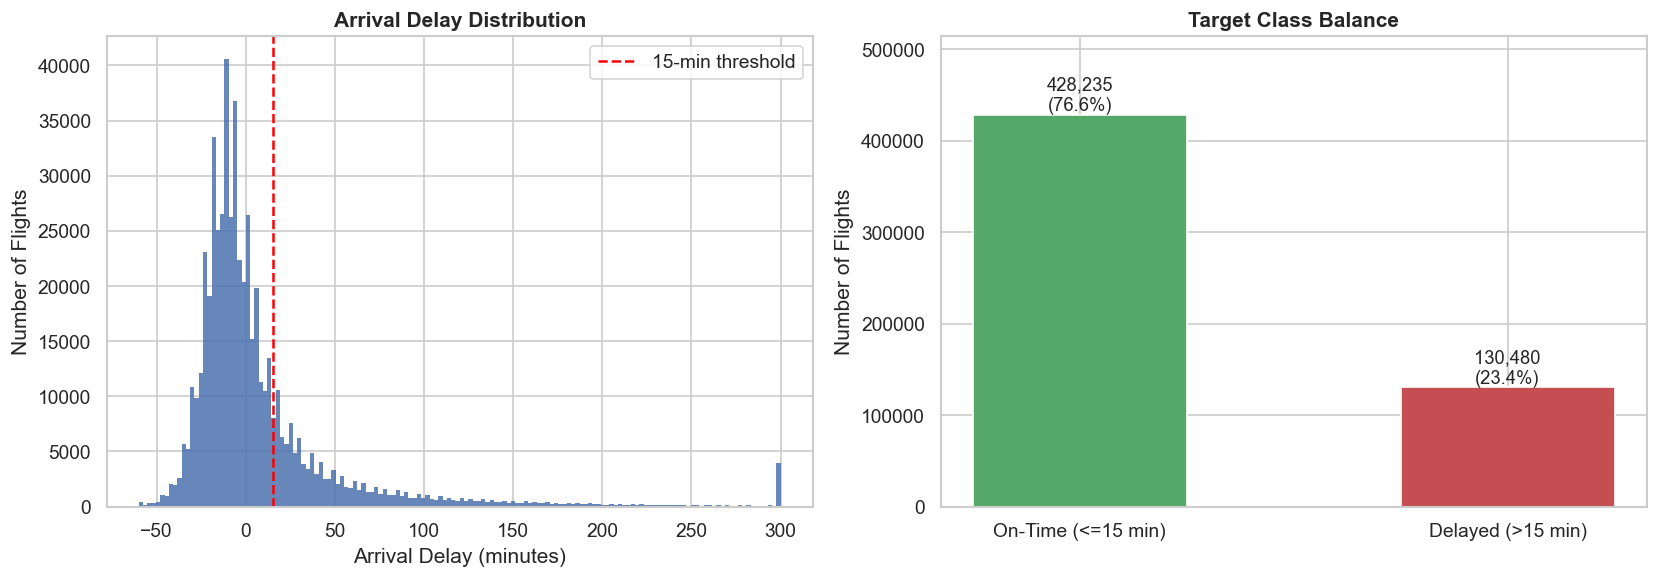

Business insight: ~76% of flights arrive on-time; 24% are delayed.
This mild imbalance warrants class_weight='balanced' during modelling.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribution clipped at 300 min
ax = axes[0]
data = df_model['ArrDelay'].clip(-60, 300)
ax.hist(data, bins=150, color='#4C72B0', edgecolor='none', alpha=0.85)
ax.axvline(15, color='red', linestyle='--', linewidth=1.5, label='15-min threshold')
ax.set_title('Arrival Delay Distribution', fontweight='bold')
ax.set_xlabel('Arrival Delay (minutes)')
ax.set_ylabel('Number of Flights')
ax.legend()

#class balance
ax2 = axes[1]
counts = df_model['ArrDel15'].value_counts().sort_index()
bars = ax2.bar(['On-Time (<=15 min)', 'Delayed (>15 min)'],
               counts.values,
               color=['#55A868', '#C44E52'], width=0.5)
for bar, val in zip(bars, counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}\n({val/len(df_model)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)
ax2.set_title('Target Class Balance', fontweight='bold')
ax2.set_ylabel('Number of Flights')
ax2.set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.show()
print("Business insight: ~76% of flights arrive on-time; 24% are delayed.")
print("This mild imbalance warrants class_weight='balanced' during modelling.")


### Plot 2 — Delay Cause Breakdown by Airline

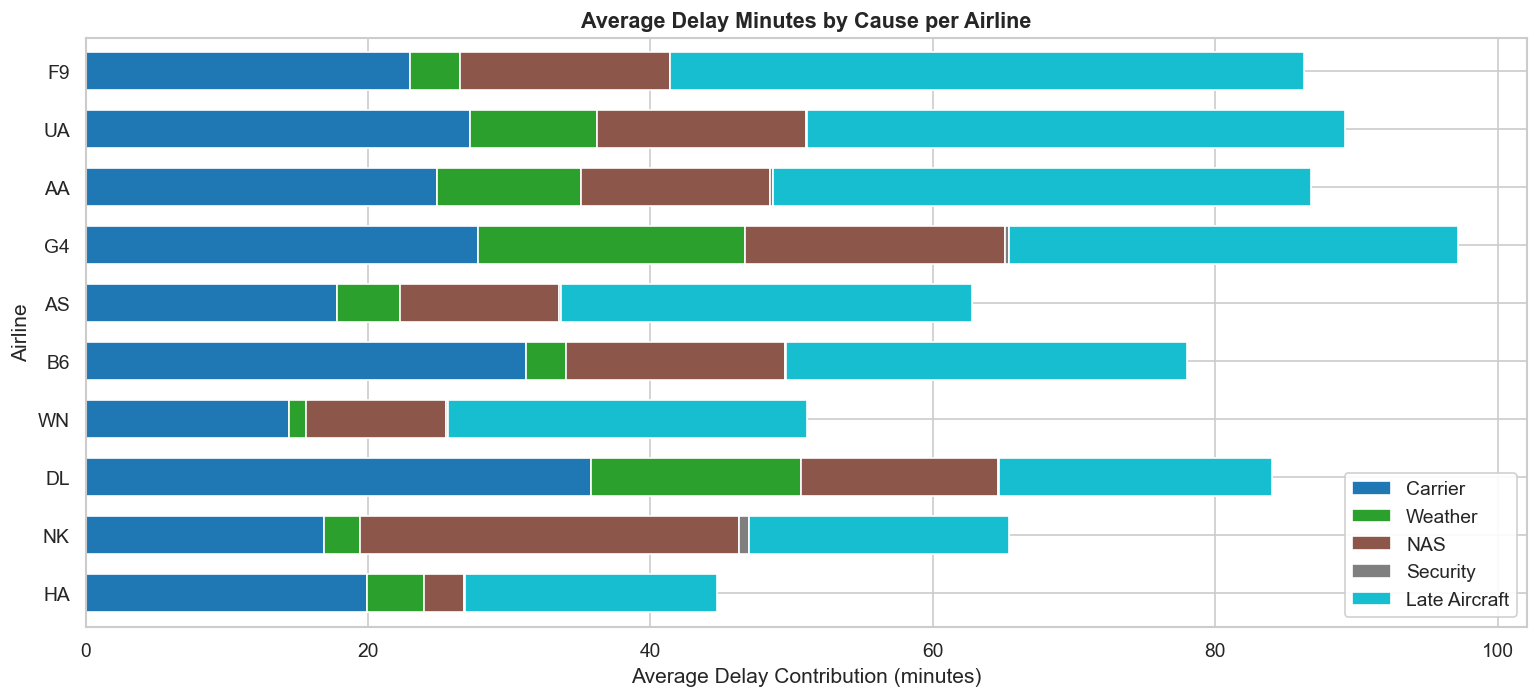

Business insight: Late-aircraft propagation dominates across all carriers.
Carriers with high Carrier share have controllable operational inefficiencies.


In [12]:
cause_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay',
              'SecurityDelay', 'LateAircraftDelay']
cause_cols = [c for c in cause_cols if c in df.columns]

cause_df = (df[cause_cols + ['Marketing_Airline_Network']]
            .dropna(subset=cause_cols, how='all')
            .groupby('Marketing_Airline_Network')[cause_cols]
            .mean()
            .round(1))

cause_df.columns = ['Carrier', 'Weather', 'NAS', 'Security', 'Late Aircraft']
cause_df.sort_values('Late Aircraft', ascending=True, inplace=True)

ax = cause_df.plot(kind='barh', stacked=True, figsize=(13, 6),
                   colormap='tab10', width=0.65)
ax.set_title('Average Delay Minutes by Cause per Airline', fontweight='bold', fontsize=13)
ax.set_xlabel('Average Delay Contribution (minutes)')
ax.set_ylabel('Airline')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()
plt.savefig('plot2_delay_causes.png', bbox_inches='tight')
plt.show()
print("Business insight: Late-aircraft propagation dominates across all carriers.")
print("Carriers with high Carrier share have controllable operational inefficiencies.")


### Plot 3 — Delay Rate by Hour of Day

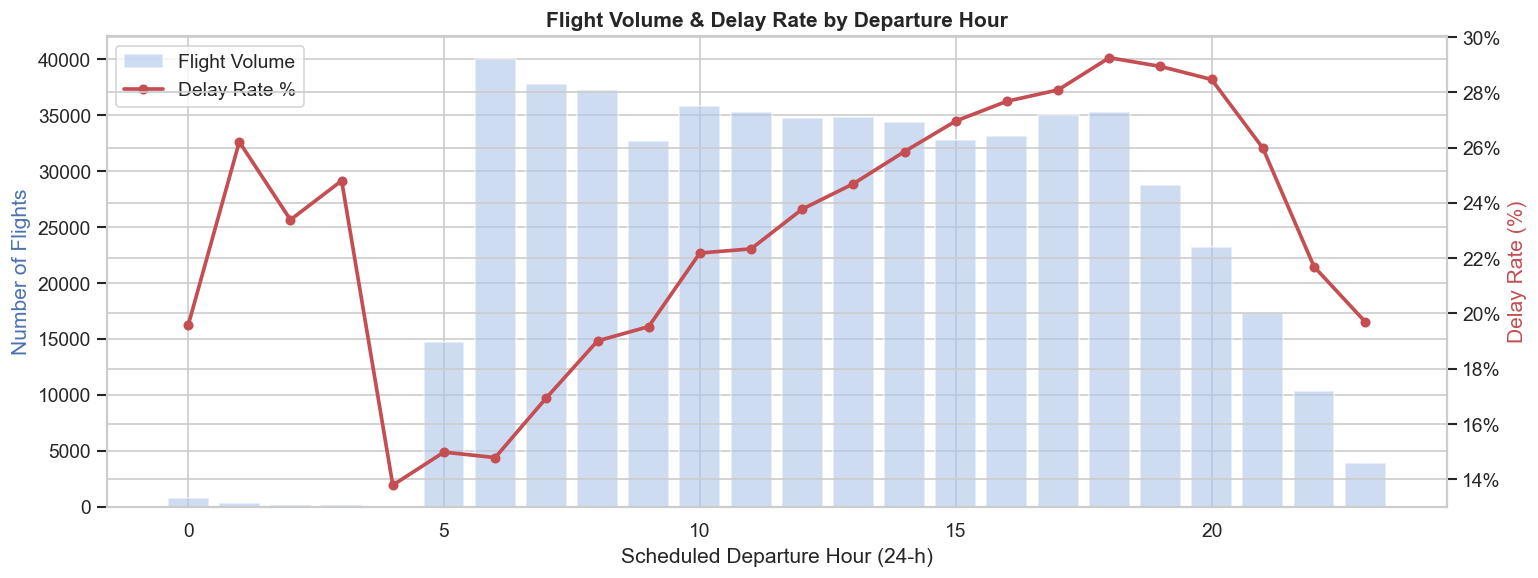

Business insight: Early-morning (5-7 AM) flights have the lowest delay rates.
Delay rates climb steadily peaking after 18:00 as cascade builds through the day.


In [14]:
df_model['DepHour'] = (df_model['CRSDepTime'] // 100).clip(0, 23)

hourly = (df_model.groupby('DepHour')['ArrDel15']
          .agg(['mean', 'count'])
          .reset_index())
hourly.columns = ['Hour', 'DelayRate', 'FlightCount']

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.bar(hourly['Hour'], hourly['FlightCount'],
        color='#AEC6E8', alpha=0.6, width=0.8, label='Flight Volume')
ax2.plot(hourly['Hour'], hourly['DelayRate'] * 100,
         color='#C44E52', marker='o', linewidth=2.2, markersize=5,
         label='Delay Rate %')

ax1.set_xlabel('Scheduled Departure Hour (24-h)')
ax1.set_ylabel('Number of Flights', color='#4C72B0')
ax2.set_ylabel('Delay Rate (%)', color='#C44E52')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Flight Volume & Delay Rate by Departure Hour', fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_hourly_pattern.png', bbox_inches='tight')
plt.show()
print("Business insight: Early-morning (5-7 AM) flights have the lowest delay rates.")
print("Delay rates climb steadily peaking after 18:00 as cascade builds through the day.")


### Plot 4 — Delay Rate at Top 15 Busiest Origin Airports

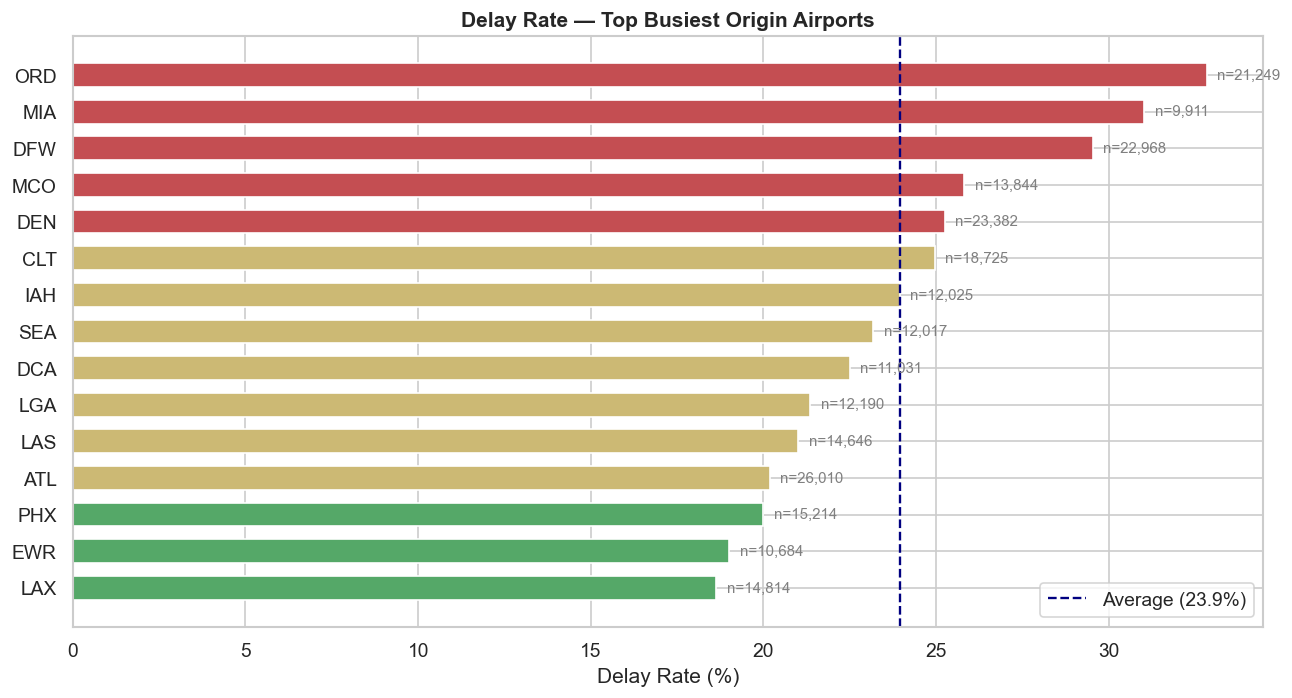

Business insight: High-volume hubs often show average or below-average delay rates
due to mature operations. Mid-size airports can have worse rates.


In [15]:
airport_stats = (df_model.groupby('Origin')
                 .agg(
                     DelayRate=('ArrDel15', 'mean'),
                     FlightCount=('ArrDel15', 'count')
                 )
                 .reset_index())

n_airports = min(15, len(airport_stats))
top_n = airport_stats.nlargest(n_airports, 'FlightCount').sort_values('DelayRate', ascending=True)
top_n['DelayRate_pct'] = top_n['DelayRate'] * 100

colors = ['#C44E52' if r > 25 else '#55A868' if r < 20 else '#CCB974'
          for r in top_n['DelayRate_pct']]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_n['Origin'], top_n['DelayRate_pct'], color=colors, height=0.65)
ax.axvline(top_n['DelayRate_pct'].mean(), color='navy', linestyle='--',
           linewidth=1.4, label=f"Average ({top_n['DelayRate_pct'].mean():.1f}%)")
for bar, cnt in zip(bars, top_n['FlightCount']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'n={cnt:,}', va='center', fontsize=9, color='gray')
ax.set_xlabel('Delay Rate (%)')
ax.set_title('Delay Rate — Top Busiest Origin Airports', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot5_airport_delay.png', bbox_inches='tight')
plt.show()
print("Business insight: High-volume hubs often show average or below-average delay rates")
print("due to mature operations. Mid-size airports can have worse rates.")


### Plot 5 — Cancellation Rate by Airline & Root Cause

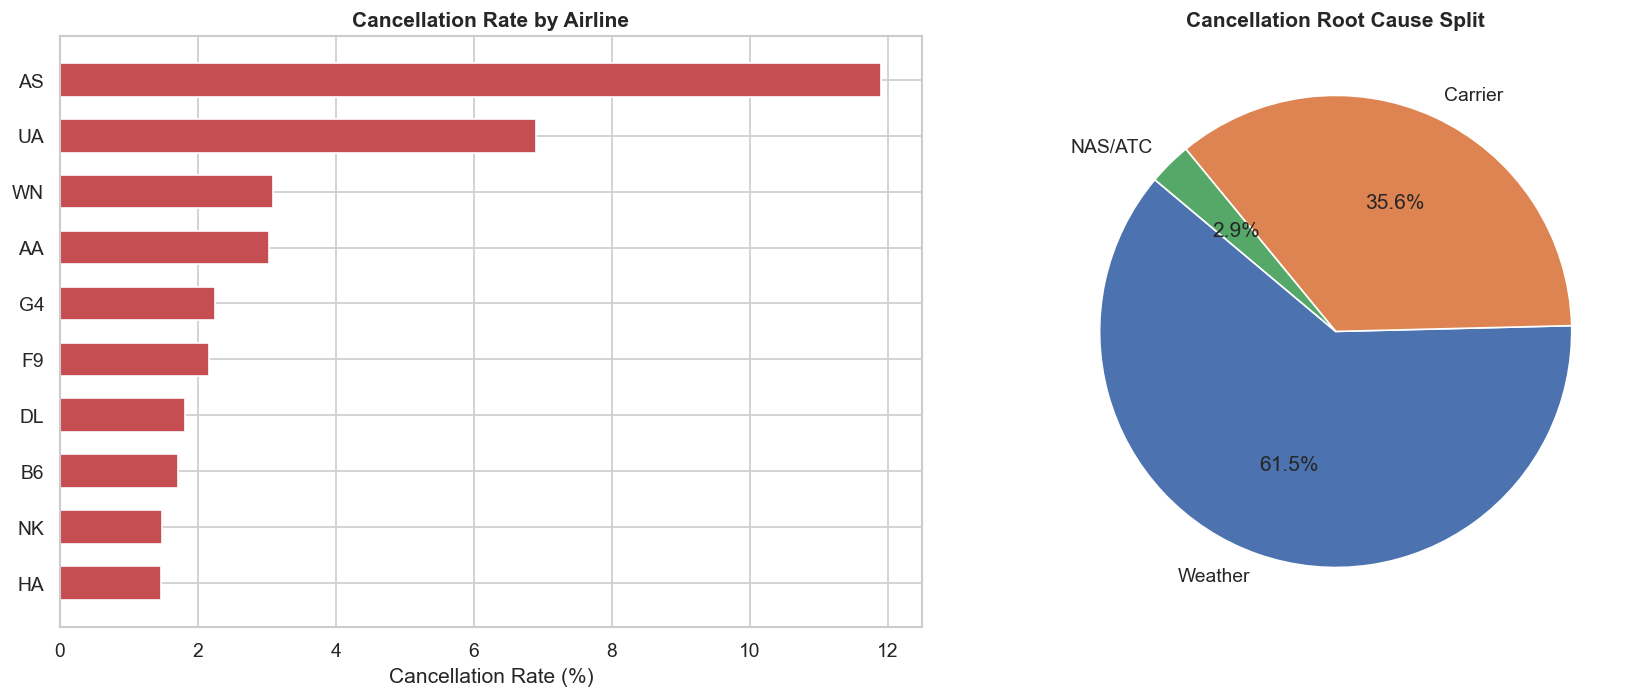

Business insight: Weather is the largest cancellation driver overall.
Carrier-related cancels highlight operational reliability differences.


In [16]:
cancel_df = df[df['Cancelled'] == 1].copy()

cancel_rate = (df.groupby('Marketing_Airline_Network')['Cancelled']
               .mean()
               .sort_values(ascending=True)
               .reset_index())
cancel_rate['CancelPct'] = cancel_rate['Cancelled'] * 100

code_map = {'A': 'Carrier', 'B': 'Weather', 'C': 'NAS/ATC', 'D': 'Security'}
code_counts = cancel_df['CancellationCode'].map(code_map).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(cancel_rate['Marketing_Airline_Network'],
             cancel_rate['CancelPct'],
             color='#C44E52', height=0.6)
axes[0].set_xlabel('Cancellation Rate (%)')
axes[0].set_title('Cancellation Rate by Airline', fontweight='bold')

if len(code_counts) > 0:
    axes[1].pie(code_counts.values, labels=code_counts.index,
                autopct='%1.1f%%', startangle=140,
                colors=['#4C72B0', '#DD8452', '#55A868', '#C44E52'][:len(code_counts)])
    axes[1].set_title('Cancellation Root Cause Split', fontweight='bold')

plt.tight_layout()
plt.savefig('plot6_cancellations.png', bbox_inches='tight')
plt.show()
print("Business insight: Weather is the largest cancellation driver overall.")
print("Carrier-related cancels highlight operational reliability differences.")


### Plot 6 — Weekly Pattern: Delay Rate & Flight Volume

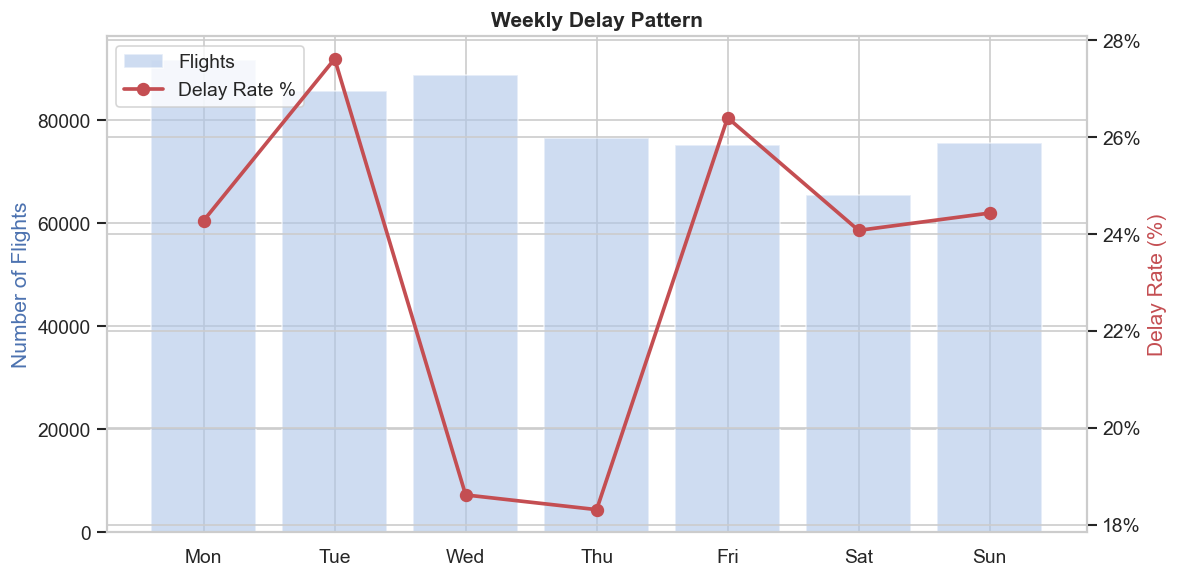

Business insight: Thursdays & Fridays tend to have higher delay rates.
Saturdays often show the lowest rates — lighter schedule, less propagation.


In [17]:
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
df_model['DayName'] = df_model['DayOfWeek'].map(day_map)

dow_stats = (df_model.groupby('DayName')['ArrDel15']
             .agg(['mean', 'count'])
             .reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
             .reset_index())
dow_stats.columns = ['Day', 'DelayRate', 'Count']

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.bar(dow_stats['Day'], dow_stats['Count'], color='#AEC6E8', alpha=0.6, label='Flights')
ax2.plot(dow_stats['Day'], dow_stats['DelayRate'] * 100,
         'o-', color='#C44E52', linewidth=2.2, markersize=7, label='Delay Rate %')
ax1.set_ylabel('Number of Flights', color='#4C72B0')
ax2.set_ylabel('Delay Rate (%)', color='#C44E52')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title('Weekly Delay Pattern', fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_weekly_pattern.png', bbox_inches='tight')
plt.show()
print("Business insight: Thursdays & Fridays tend to have higher delay rates.")
print("Saturdays often show the lowest rates — lighter schedule, less propagation.")


### Plot 7 — Correlation Matrix of Delay & Operational Variables

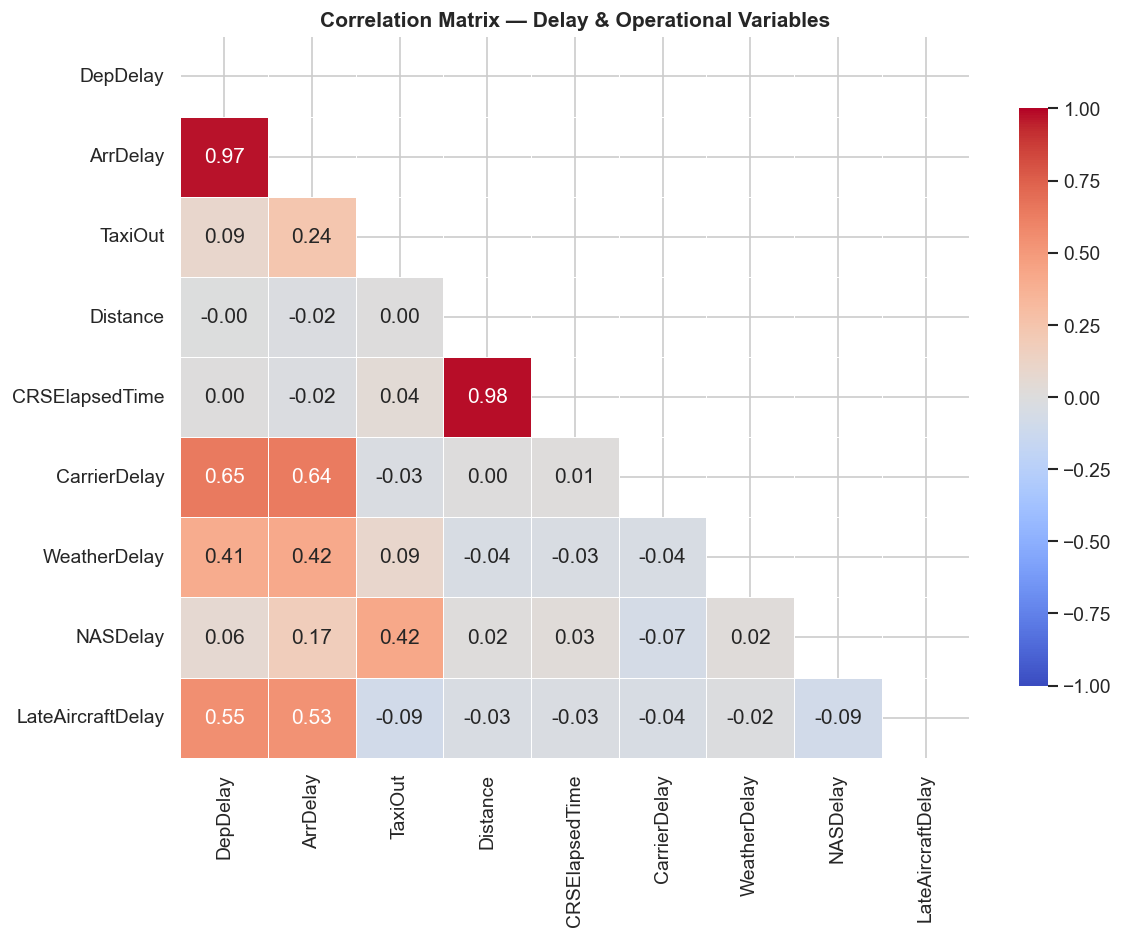

Business insight: DepDelay->ArrDelay correlation ~0.95: departure delays
nearly always translate to arrival delays. LateAircraftDelay highly correlated
with DepDelay, confirming rotation propagation as the primary driver.


In [18]:
corr_cols_all = ['DepDelay', 'ArrDelay', 'TaxiOut', 'Distance',
             'CRSElapsedTime', 'CarrierDelay', 'WeatherDelay',
             'NASDelay', 'LateAircraftDelay']
corr_cols_all = [c for c in corr_cols_all if c in df_model.columns]
corr = df_model[corr_cols_all].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.4, linecolor='white',
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Delay & Operational Variables', fontweight='bold')
plt.tight_layout()
plt.savefig('plot8_correlation.png', bbox_inches='tight')
plt.show()
print("Business insight: DepDelay->ArrDelay correlation ~0.95: departure delays")
print("nearly always translate to arrival delays. LateAircraftDelay highly correlated")
print("with DepDelay, confirming rotation propagation as the primary driver.")


### Plot 8 — Delay Rate by Route Distance Segment

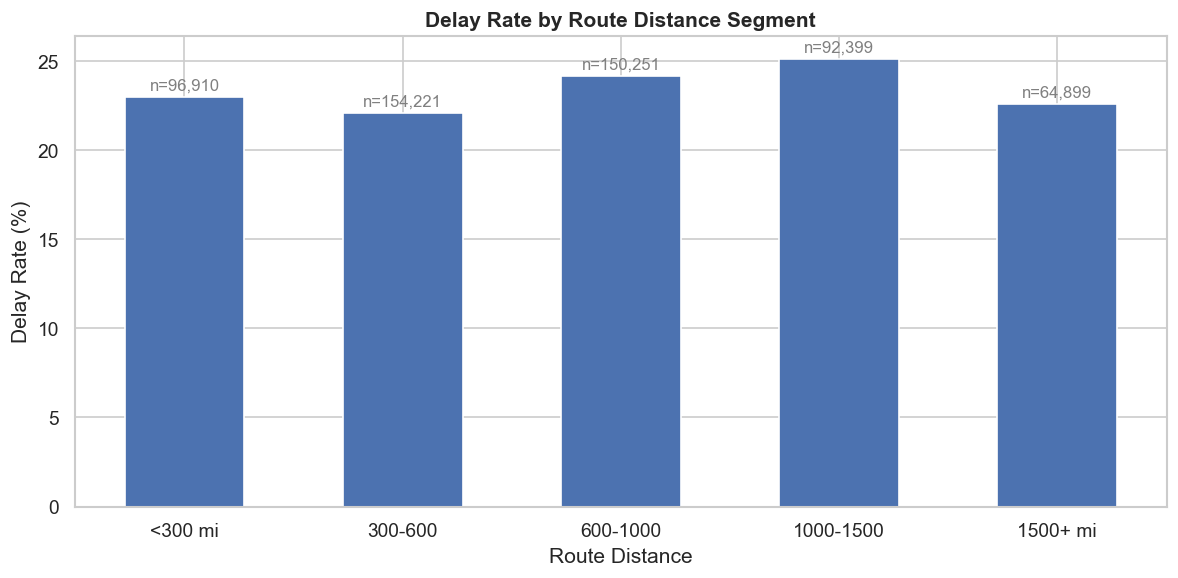

No such pattern here


In [20]:
bins   = [0, 300, 600, 1000, 1500, 5000]
labels_d = ['<300 mi', '300-600', '600-1000', '1000-1500', '1500+ mi']
df_model['DistanceBucket'] = pd.cut(df_model['Distance'], bins=bins, labels=labels_d)

dist_delay = (df_model.groupby('DistanceBucket', observed=True)['ArrDel15']
              .agg(['mean', 'count'])
              .reset_index())
dist_delay.columns = ['DistanceBucket', 'DelayRate', 'Count']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dist_delay['DistanceBucket'],
              dist_delay['DelayRate'] * 100,
              color='#4C72B0', width=0.55)
for bar, row in zip(bars, dist_delay.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'n={row.Count:,}', ha='center', fontsize=10, color='gray')
ax.set_xlabel('Route Distance')
ax.set_ylabel('Delay Rate (%)')
ax.set_title('Delay Rate by Route Distance Segment', fontweight='bold')
plt.tight_layout()
plt.savefig('plot9_distance_bucket.png', bbox_inches='tight')
plt.show()
print("No such pattern here")
